In [1]:
# 1. Importowanie bibioltek i danych źródłowych
import pandas as pd
import numpy as np
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [2]:
# 2. Przygotowanie danych do analizy

## Filtrowanie odpowiedzi dotyczących wrażliwości na kontrast
df_smoking = df[df["Question"] == "Contrast sensitivity"]

## Uwzglednienie tylko surowych danych, a nie przeliczonych do norm wiekowych
df_smoking = df_smoking[df_smoking["Data_Value_Type"] == "Crude Prevalence"]

## Usuwanie pustych wierszy
df_smoking = df_smoking.dropna(subset=["Data_Value", "Response"])

# Filtrowanie danych - pozostawienie z czynników ryzyka danych dotyczących palenia
df_smoking = df_smoking[df_smoking["RiskFactor"] == "Smoking"]

# Wyeliminowanie duplikacji - filtrowanie odpowiedzi dla obu płci, wszystkich ras i każdego wieku
df_smoking = df_smoking[df_smoking["Sex"] == "Both sexes"]
df_smoking = df_smoking[df_smoking["RaceEthnicity"] == "All races"]
df_smoking = df_smoking[df_smoking["Age"] == "65 years and older"]


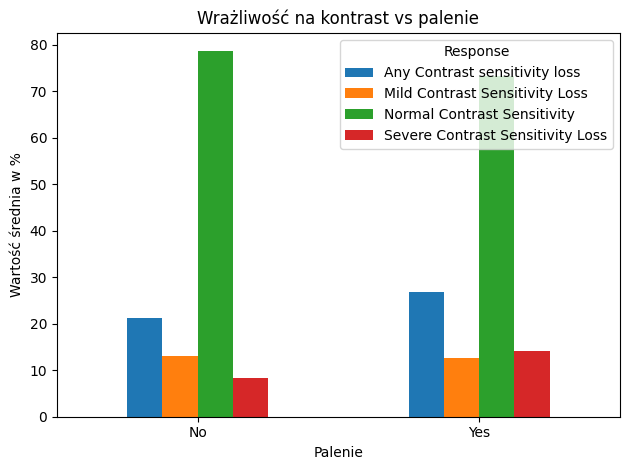

In [ ]:
# 3. Rozkład kategorii wrażliwości na kontrast według statusu palenia
# wykres słupkowy roboczy zbiorczy
# Importowanie biblioteki
import matplotlib.pyplot as plt

# Grupowanie odpowiedzi
counts = df_smoking.groupby(["RiskFactorResponse", "Response"])["Data_Value"].mean().unstack()

# wykres
counts.plot(kind="bar")

plt.xlabel("Palenie")
plt.ylabel("Wartość średnia w %")
plt.title("Wrażliwość na kontrast vs palenie")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


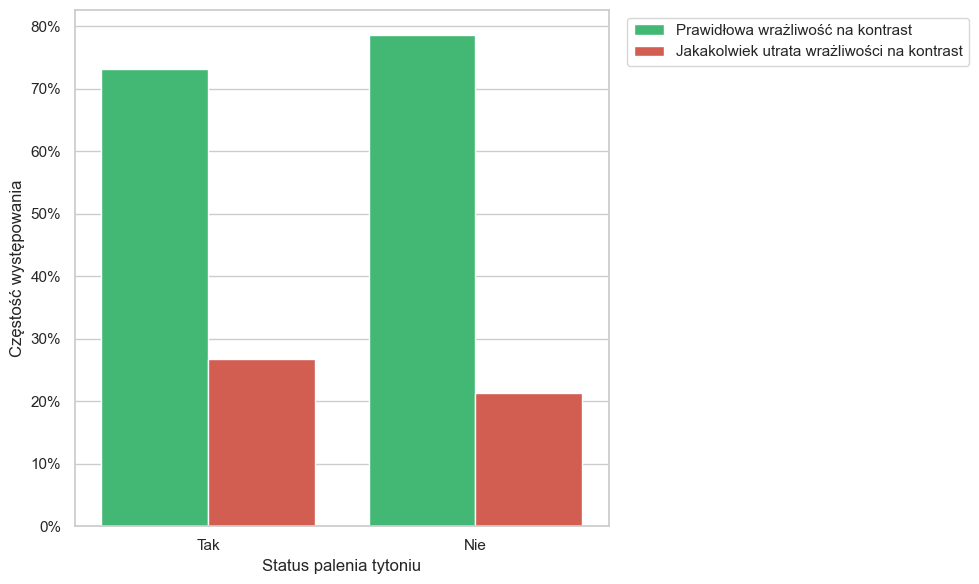

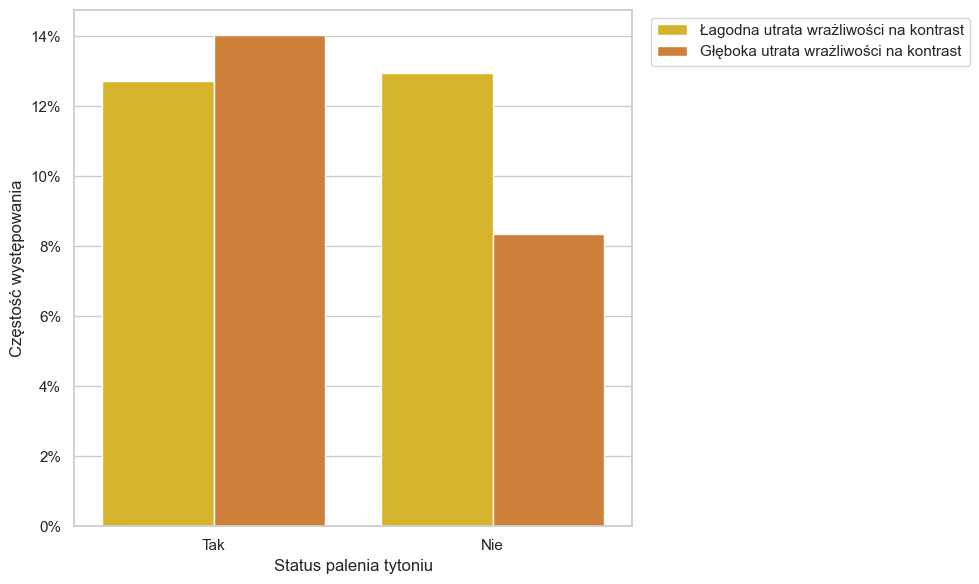

In [ ]:
# 3. Rozkład kategorii wrażliwości na kontrast według statusu palenia
# Tworzenie 2 wykresów słupkowych
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Ustawienie globalnego stylu i siatki (spójność z poprzednimi wykresami)
sns.set_theme(style="whitegrid")

# Polskie etykiety dla osi X
etykiety_x = ["Tak", "Nie"]

#Wykres1:
#Częstość występowania prawidłowej oraz obniżonej wrażliwości na kontrast w zależności od statusu palenia tytoniu przez pacjentów.

# Filtrowanie po oryginalnych angielskich nazwach
kategorie_ang_1 = ["Normal Contrast Sensitivity", "Any Contrast sensitivity loss"]
df_smoke_graph1 = df_smoking[df_smoking["Response"].isin(kategorie_ang_1)]

# Definiowanie kolorów
kolory_wykres_1 = {
    "Normal Contrast Sensitivity": "#2ecc71",
    "Any Contrast sensitivity loss": "#e74c3c",
}

plt.figure(figsize=(10, 6))

ax1 = sns.barplot(
    data=df_smoke_graph1,
    x="RiskFactorResponse",  # Status palenia na osi X
    y="Data_Value",
    hue="Response",
    hue_order=kategorie_ang_1,
    palette=kolory_wykres_1,
    errorbar=None,  # Pokazuje średnią bez pasków błędu
)

# Formatowanie osi Y na procenty (%)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Opisy osi i wstrzyknięcie polskich etykiet X
plt.xlabel("Status palenia tytoniu", fontsize=12)
plt.ylabel("Częstość występowania", fontsize=12)
plt.xticks(
    ticks=range(len(etykiety_x)), labels=etykiety_x, rotation=0, ha="center"
)

# Podmiana angielskich napisów na polskie w legendzie
polskie_etykiety_1 = [
    "Prawidłowa wrażliwość na kontrast",
    "Jakakolwiek utrata wrażliwości na kontrast",
]
ax1.legend(
    labels=polskie_etykiety_1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


# Wykres 2:
#Porównanie częstości występowania łagodnej i głębokiej utraty wrażliwości na kontrast w zależności od statusu palenia tytoniu przez pacjentów.

# Filtrowanie po oryginalnych angielskich nazwach
kategorie_ang_2 = [
    "Mild Contrast Sensitivity Loss",
    "Severe Contrast Sensitivity Loss",
]
df_smoke_graph2 = df_smoking[df_smoking["Response"].isin(kategorie_ang_2)]

# Definiowanie kolorów
kolory_wykres_2 = {
    "Mild Contrast Sensitivity Loss": "#f1c40f",
    "Severe Contrast Sensitivity Loss": "#e67e22",
}

plt.figure(figsize=(10, 6))

ax2 = sns.barplot(
    data=df_smoke_graph2,
    x="RiskFactorResponse",  # Status palenia na osi X
    y="Data_Value",
    hue="Response",
    hue_order=kategorie_ang_2,
    palette=kolory_wykres_2,
    errorbar=None,
)

# Formatowanie osi Y na procenty (%)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Opisy osi i wstrzyknięcie polskich etykiet X
plt.xlabel("Status palenia tytoniu", fontsize=12)
plt.ylabel("Częstość występowania", fontsize=12)
plt.xticks(
    ticks=range(len(etykiety_x)), labels=etykiety_x, rotation=0, ha="center"
)

# Podmiana angielskich napisów na polskie w legendzie
polskie_etykiety_2 = [
    "Łagodna utrata wrażliwości na kontrast",
    "Głęboka utrata wrażliwości na kontrast",
]
ax2.legend(
    labels=polskie_etykiety_2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [ ]:
# 4. Test niezależności chi-kwadrat i współczynnik V Craméra

## Importowanie bibliotek
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

## Usunięcie odpowiedzi, które nie będą uwzględnione w analizie
exclude_responses = ['Mild Contrast Sensitivity Loss','Severe Contrast Sensitivity Loss']
df_filtered_smoking = df_smoking[
    (~df_smoking["Response"].isin(exclude_responses)) & 
    (df_smoking["NonWeightedSample"].notna())
].copy()

## Tworzenie tabeli kontyngencji (szacowanie liczebności)
### Wyznaczanie średniej wielkość grupy dla każdej kategorii wiekowej (zabezpieczenie przed duplikacją)
group_sizes = pd.crosstab(
    df_filtered_smoking["RiskFactorResponse"], 
    df_filtered_smoking["Response"], 
    values = df_filtered_smoking["NonWeightedSample"], 
    aggfunc="mean"
).fillna(0)
### Wyznaczanie średnie wartości procentowe dla danej kategorii
percentages = pd.crosstab(
    df_filtered_smoking["RiskFactorResponse"], 
    df_filtered_smoking["Response"], 
    values=df_filtered_smoking["Data_Value"], 
    aggfunc="mean"
).fillna(0)

### Ostateczna wersja tabeli kontyngencji (przeliczenie procentów na liczby osób)
contingency = (percentages * group_sizes) / 100


## Wykonanie testu niezależności Chi-kwadrat Pearsona
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency)

## Obliczenie V Cramera
def calculate_cramers_v(chi2, table):
    n = table.values.sum() 
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

v_cramera = calculate_cramers_v(chi2_stat, contingency)

## Prezentacja wyników
print("TABELA KONTYNGENCJI (Szacowane liczby osób):")
print(contingency.round(1))
print("-" * 50)
print(f"ANALIZA STATYSTYCZNA: Wrażliwość na kontrast vs Palenie")
print(f"Liczebność próby (N):    {contingency.values.sum():.0f}")
print(f"Statystyka Chi2:         {chi2_stat:.4f}")
print(f"Wartość p:               {p_value:.4e}")
print(f"Stopnie swobody:         {dof}")
print(f"Współczynnik V Craméra:  {v_cramera:.4f}")
      
# Interpretacja jakościowa wg klasyfikacji Jacoba Cohena
if p_value < 0.05:
    if v_cramera < 0.1:
        strength = "pomijalna"
    elif v_cramera < 0.3:
        strength = "słaba"
    elif v_cramera < 0.5:
        strength = "umiarkowana"
    else:
        strength = "silna"
    print(f"Wniosek: Zależność istotna statystycznie, siła związku: {strength}.")
else:
    print("Wniosek: Brak istotnych statystycznie podstaw do odrzucenia hipotezy o niezależności.")




TABELA KONTYNGENCJI (Szacowane liczby osób):
Response            Any Contrast sensitivity loss  Normal Contrast Sensitivity
RiskFactorResponse                                                            
No                                          462.4                       1706.6
Yes                                          93.1                        254.9
--------------------------------------------------
ANALIZA STATYSTYCZNA: Wrażliwość na kontrast vs Palenie
Liczebność próby (N):    2517
Statystyka Chi2:         4.8482
Wartość p:               2.7675e-02
Stopnie swobody:         1
Współczynnik V Craméra:  0.0439
Wniosek: Zależność istotna statystycznie, siła związku: pomijalna.
